# Debug track walking: left versus right foot

This investigation reproduces the track-bout selection in `demo_colab_one_foot.ipynb`, reads the **two different sensor files**, and runs mechanization headlessly. The selected bout is about 128 s, near 16:34 on 29 October 2025. The supplied context is an indoor 200 m track; no surveyed trajectory or exact start/finish marker is available.

**Finding on this bout:** gravity-vector tilt correction **plus** gyro-bias calibration from the preceding quiet interval reduces time-aligned XY disagreement from **5.32 m to 1.12 m RMSE**. Contact-to-contact distance remains **197.6 / 199.9 m**, and endpoint gaps reduce from **8.4 / 14.9 m** to **2.6 / 3.9 m**. These are consistency checks, not proof of absolute accuracy. The existing backend remains unchanged; the candidate is explicitly experimental.

The full reproducible implementation is `scripts/debug_track_foot_difference.py`; run it from the repository root with `.venv/bin/python scripts/debug_track_foot_difference.py`. Run this notebook from the repo root or `notebooks/` using the project environment. It uses no uploads, widgets, network installs, or display server.

In [1]:
from pathlib import Path
import sys, os
ROOT = Path.cwd() if (Path.cwd() / 'src/stride_imu').exists() else Path.cwd().parent
assert (ROOT / 'scripts/debug_track_foot_difference.py').exists(), 'Run from repo root or notebooks/'
sys.path.insert(0, str(ROOT / 'scripts'))
import debug_track_foot_difference as debug
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from stride_imu.experimental import compute_position_experimental
import stride_imu as imu
OUT = debug.DEFAULT_OUTPUT
pd.set_option('display.max_columns', 20)

def show_figure(fig, filename):
    path = OUT / filename
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(path)))

## 1. Extract the same bout and audit the inputs

Copied from the demo: local target 16:34, ±240 s search, longest matching bout, quiet thresholds 30 deg/s and 1 m/s², minimum quiet 1.5 s and walking 3 s. Select independently on both feet, show every candidate, then extract the union of the selected timestamp intervals. The sensors start at different times; scoring interpolates onto a common 0.1 s grid rather than comparing sample indices.

`FOOT_LABEL` in the original demo is only a label. Its `FOOT_FILE` remains the LF recording unless explicitly changed. Also, its plotting helpers use dictionary indexing although this checkout returns `FootTrajectory` dataclasses; this notebook uses `.P`, `.FF`, etc.

In [2]:
data, metadata = debug.extract_track_bout(OUT)
display(pd.DataFrame([dict(foot=side, **row) for side, candidates in metadata['candidates'].items() for row in candidates]))
display(pd.DataFrame(metadata['selected']).T)
display(pd.DataFrame(metadata['calibration']).T)
print('Sampling rate:', 1 / float(data['period']), 'Hz')

,foot,start,duration_s
0,left,2025-10-29T16:31:23.577875-06:00,112.929688
1,left,2025-10-29T16:33:18.070062-06:00,41.148438
2,left,2025-10-29T16:34:01.273187-06:00,3.718750
3,left,2025-10-29T16:34:27.476312-06:00,128.195312
4,right,2025-10-29T16:31:23.998687-06:00,113.414062
5,right,2025-10-29T16:33:22.545562-06:00,31.531250
6,right,2025-10-29T16:34:05.420562-06:00,4.789062
7,right,2025-10-29T16:34:27.881500-06:00,127.343750


,start,end,start_idx,end_idx,samples,independent_duration_s
left,2025-10-29T16:34:27.476312-06:00,2025-10-29T16:36:35.663812-06:00,394553,410962,16409,128.195312
right,2025-10-29T16:34:27.483062-06:00,2025-10-29T16:36:35.662750-06:00,393845,410253,16408,127.34375


,before_seconds,after_seconds,before_bias_deg_s,after_bias_deg_s
left,16.867188,8.046875,"[0.12579028742701812, 0.0, -0.11882761285152528]","[0.06096079905759807, 0.0, -0.06126504009090273]"
right,11.03125,7.65625,"[-0.46646447906953153, 0.007528790464879174, 0...","[-0.4819927418036787, 0.0, 0.10734085133439931]"


Sampling rate: 128.0 Hz


## 2. Reproduce, then vary one mechanism at a time

`baseline` calls the existing `compute_position`. Other runs call the opt-in `stride_imu.experimental.compute_position_experimental` with the same integration and ZUPT order. It exposes independent tilt gates, scalar filter noise, a real tilt-off switch, and an explicit body-frame gyro bias in **rad/s**. IMU input `W` remains **rad/sample**.

The first four runs isolate legacy, bias only, gravity correction only, and their combination. The following runs examine post-walk calibration, tilt gates, gain, and footfall thresholds. Calibration is a per-axis median over the separately detected quiet interval; no parameter is fitted to force a 200 m lap or close the path. Bias correction affects attitude integration; raw signals still determine contacts and tilt gating.

Metrics: `stance_distance_m` is the sum of horizontal contact-to-contact chords. `raw_3d_distance_m` matches the demo's samplewise 3D foot-path sum, including foot swing, and is not track circumference. `pair_rmse_m` compares continuous XY paths at matched times after translation and initial 10-second heading alignment, with **no scaling, reflection, nonlinear warp, or forced closure**. Feet have different instantaneous swing phases, so zero disagreement is not expected.

In [3]:
results, metrics = debug.run_experiments(data, OUT)
columns = ['experiment','foot','stance_distance_m','raw_3d_distance_m','endpoint_gap_m',
           'elevation_range_m','contacts','tilt_samples','pair_rmse_m','pair_p95_m']
display(metrics[columns].round(3))

baseline                 pair RMSE   5.32 m; contacts 129/130


legacy_bias              pair RMSE   6.37 m; contacts 129/130


gravity_only             pair RMSE   9.72 m; contacts 129/130


gravity_bias             pair RMSE   1.12 m; contacts 129/130


gravity_bias_after       pair RMSE   3.31 m; contacts 129/130


...

gravity_bias_a0.5        pair RMSE   1.12 m; contacts 129/130


gravity_bias_a2          pair RMSE   0.99 m; contacts 129/130


gravity_bias_q0.1        pair RMSE   1.66 m; contacts 129/130


gravity_bias_q10         pair RMSE   1.08 m; contacts 129/130


,experiment,foot,stance_distance_m,raw_3d_distance_m,endpoint_gap_m,elevation_range_m,contacts,tilt_samples,pair_rmse_m,pair_p95_m
0,baseline,left,197.531,208.140,8.368,1.644,129,3875,5.324,10.007
1,baseline,right,199.791,210.959,14.925,6.239,130,3068,5.324,10.007
2,legacy_bias,left,197.607,208.211,3.934,1.666,129,3875,6.369,11.898
3,legacy_bias,right,199.854,211.053,11.993,6.904,130,3068,6.369,11.898
4,gravity_only,left,197.540,208.143,2.995,1.688,129,3875,9.724,17.596
5,gravity_only,right,199.845,210.970,14.378,5.265,130,3068,9.724,17.596
6,gravity_bias,left,197.615,208.214,2.614,1.714,129,3875,1.122,2.222
7,gravity_bias,right,199.912,211.065,3.911,5.917,130,3068,1.122,2.222
8,gravity_bias_after,left,197.578,208.179,2.692,1.701,129,3875,3.314,6.325
9,gravity_bias_after,right,199.950,211.103,6.884,6.194,130,3068,3.314,6.325


## 3. Separate the plotting artifact from trajectory error

The demo aligns **start-to-end displacement** with +Y. That direction is ill-conditioned for a nearly closed lap: a few metres of endpoint drift can rotate the whole plotted track substantially. Initial travel gives a more stable comparison. This corrects the presentation; the remaining separation is an estimation issue.

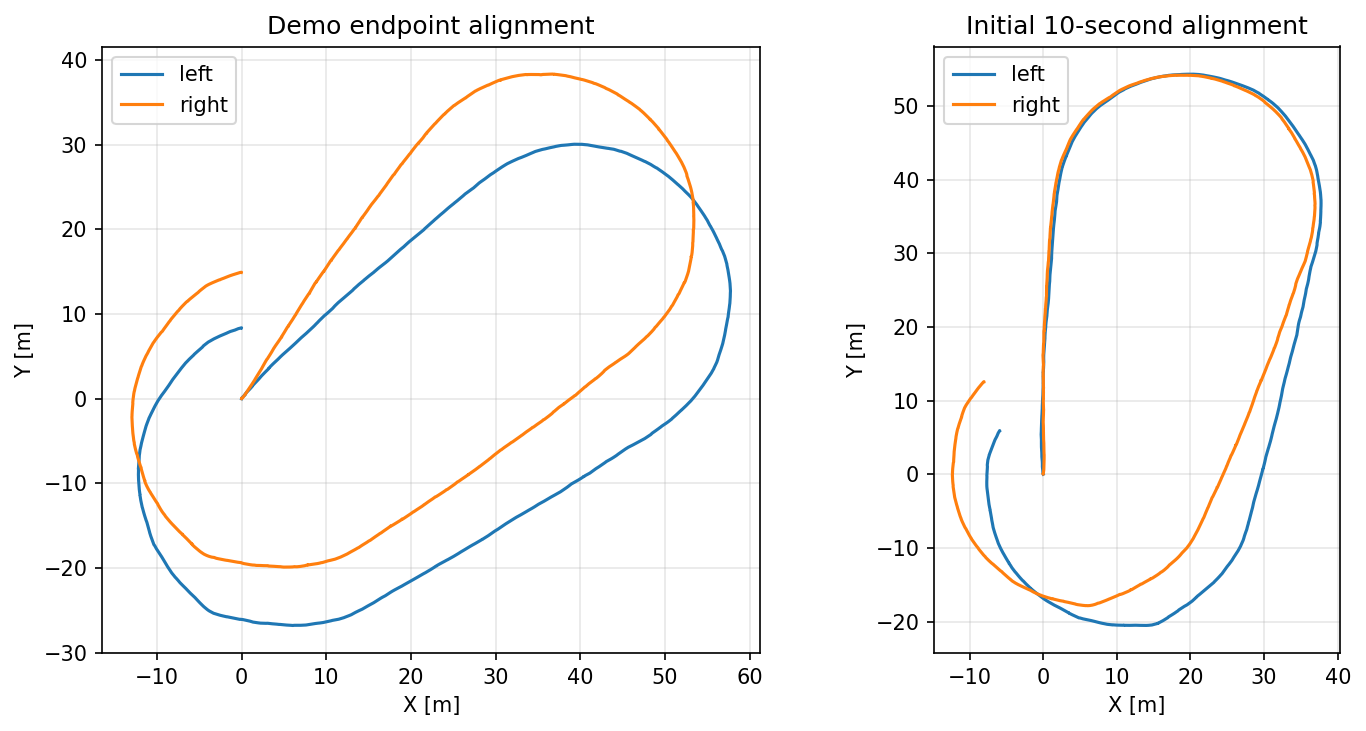

In [4]:
show_figure(debug.plot_alignment_artifact(results, data), 'alignment.png')

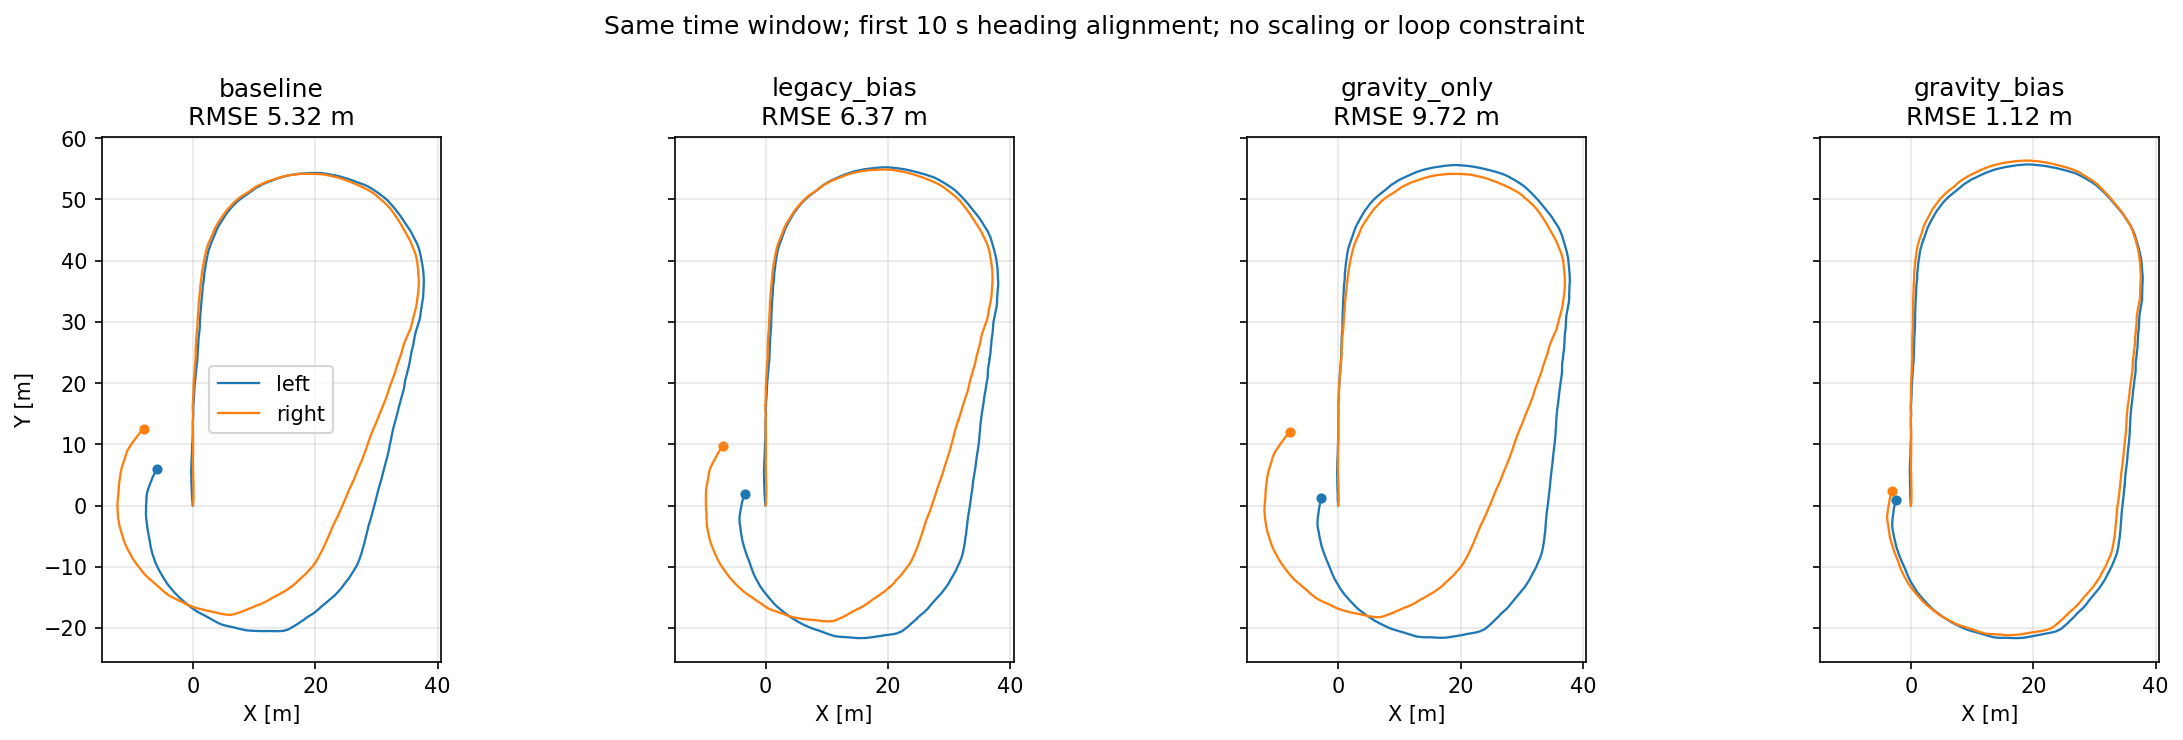

In [5]:
show_figure(debug.plot_trajectory_comparison(results, data), 'trajectories.png')

## 4. RPY and tight turns

The legacy `kalman_filter_tilt` blends accelerometer-derived roll/pitch while preserving Euler yaw. The candidate uses the same scalar covariance/gain schedule but corrects the gravity vector with a quaternion rotation about a horizontal navigation-frame axis. It does not observe or clamp heading. This changes how tilt correction interacts with orientation and gyro bias.

Swing pitch approaches ±90°, so continuously unwrapping Euler yaw across all samples produces thousands of apparent degrees of rotation. That is not the number of track turns. Below, contact-sampled yaw and contact-to-contact travel direction are more useful. Near-singular swing Euler angles alone do **not** prove that the gated stance update is the cause; the ablation results implicate the combined tilt/bias treatment.

The two feet have different swing-rate distributions. Tightening the shared angular-rate threshold to 10 deg/s removes most contacts (30/25 instead of 129/130) and wrecks the path. Separate tilt gates preserve ZUPT contacts. Changing thresholds or gain alone was weaker than the combined correction, and either bias-only or gravity-only actually worsened pair agreement.

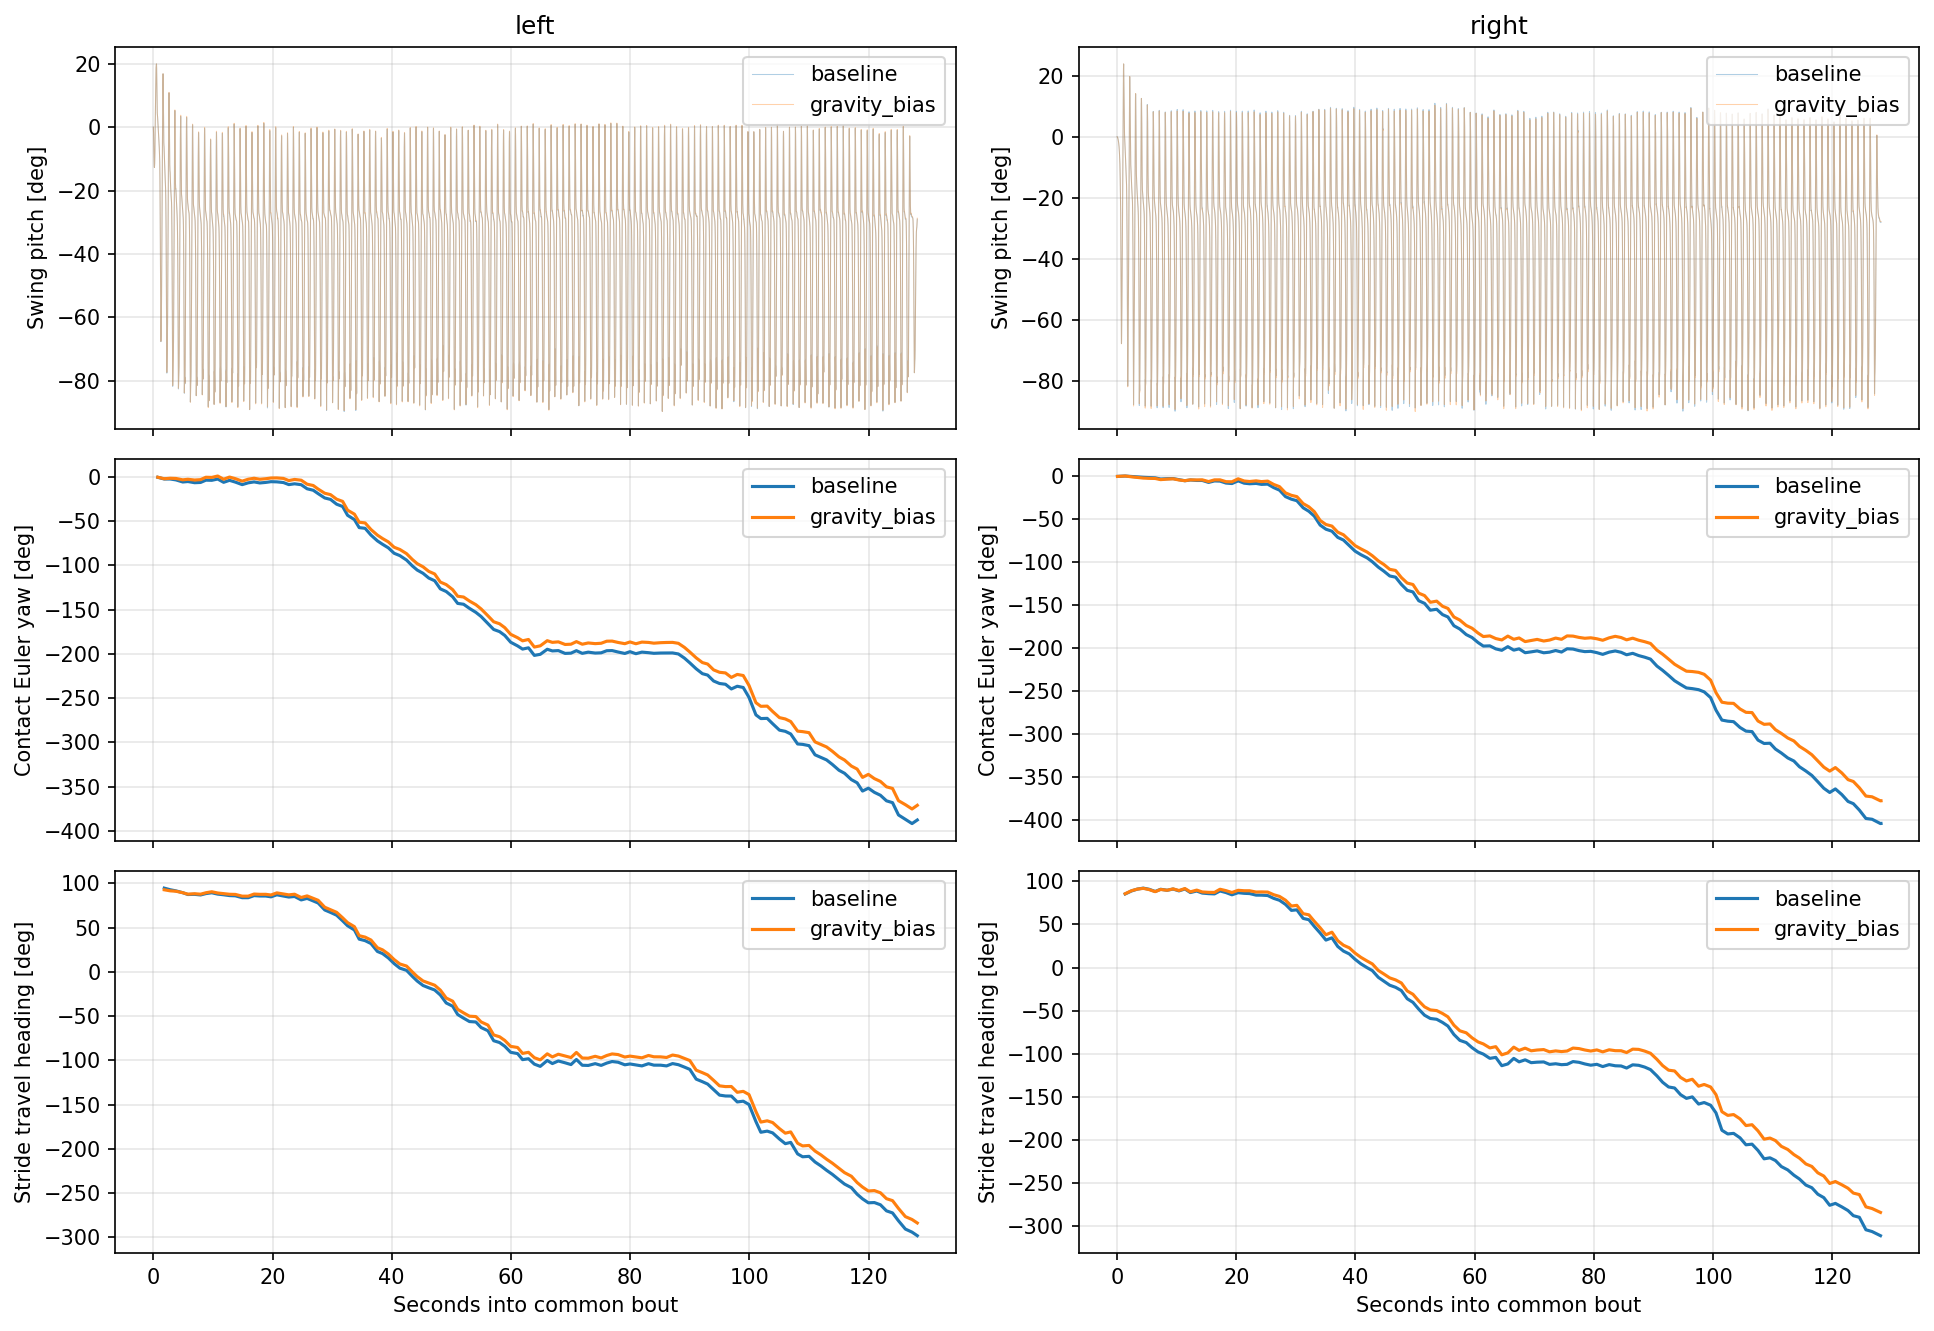

In [6]:
show_figure(debug.plot_orientation(results, data), 'orientation.png')

In [7]:
diagnostics = []
for side in debug.FILES:
    r = results['baseline'][side]
    diagnostics.append(dict(foot=side,
        gyro_p99_deg_s=np.percentile(np.rad2deg(np.linalg.norm(data[side+'_W'],axis=1)/float(data['period'])),99),
        max_abs_pitch_deg=np.max(np.abs(np.rad2deg(r.euler[:,1]))),
        contact_yaw_change_deg=np.rad2deg(np.diff(np.unwrap(r.euler[r.FF,2]))).sum()))
display(pd.DataFrame(diagnostics).round(2))

,foot,gyro_p99_deg_s,max_abs_pitch_deg,contact_yaw_change_deg
0,left,676.09,89.62,-387.07
1,right,731.53,89.73,-404.45


## 5. Sensitivity and compatibility

Keep the original gate/gain values as a conservative experimental starting point: tilt 30 deg/s, acceleration residual 1 m/s², process noise 1e-5 and measurement noise 0.1 per sample; contacts retain 30 deg/s, 1 m/s², 0.4 s. A looser acceleration gate gives slightly lower RMSE here, but a single bout does not justify choosing it as a universal default.

Check heading alignment over 5/10/15 s to show that the improvement is not peculiar to a single plotting choice. The post-walk bias estimate is a separate calibration sensitivity check, **not held-out trajectory validation**. Its higher error shows that calibration quality matters.

In [8]:
display(pd.DataFrame([
    dict(experiment=name, alignment_seconds=seconds,
         pair_rmse_m=debug.score_pair(results[name],data,seconds)[0])
    for name in ['baseline','gravity_bias','gravity_bias_after'] for seconds in [5.,10.,15.]
]).round(3))
# Real-data compatibility of the experimental legacy ablation with the original.
for side in debug.FILES:
    old = results['baseline'][side]
    legacy = compute_position_experimental(data[side+'_W'], data[side+'_A'], float(data['period']), tilt_method='legacy')
    for key in vars(old):
        np.testing.assert_allclose(getattr(old,key),getattr(legacy,key),rtol=1e-11,atol=1e-11,err_msg=f'{side}: {key}')
    ignored_switch = imu.compute_position(data[side+'_W'],data[side+'_A'],float(data['period']),USE_KF=0)
    np.testing.assert_array_equal(old.P,ignored_switch.P)
print('Both real-data legacy comparisons passed; legacy USE_KF=0 is confirmed to be a no-op.')

,experiment,alignment_seconds,pair_rmse_m
0,baseline,5.0,5.240
1,baseline,10.0,5.324
2,baseline,15.0,5.401
3,gravity_bias,5.0,1.536
4,gravity_bias,10.0,1.122
5,gravity_bias,15.0,1.107
6,gravity_bias_after,5.0,3.226
7,gravity_bias_after,10.0,3.314
8,gravity_bias_after,15.0,3.355


Both real-data legacy comparisons passed; legacy USE_KF=0 is confirmed to be a no-op.


## 6. Opt-in use and remaining work

Use the new function explicitly; `compute_position`, `compute_position_two_imus`, and existing demos retain their behavior. Comments in both old and new implementations cross-reference the alternative. The existing two-foot wrapper does not fuse heading; it calls each foot independently and later re-detects contacts using hard-coded thresholds, so it is not used to hide these single-foot effects.

The combined correction is a promising **horizontal-track** improvement on this recording. It does not yet solve elevation drift (the right-foot vertical range remains about 5.9 m), prove the true track radius, or establish which foot has the correct absolute trajectory. Natural lane offsets and different swing paths also mean the feet should not be forced to coincide exactly. There is no external heading reference, surveyed path, or independent recording validation here. Before changing defaults, validate more laps, opposite turning direction, different walkers/mounts, and independently verified stationary calibration; retain an absolute heading reference if available.

In [9]:
# Example: one foot, opt-in. The script applies this independently to both feet.
side = 'left'
track = compute_position_experimental(
    data[side+'_W'], data[side+'_A'], float(data['period']),
    tilt_method='gravity', gyro_bias_rad_s=data[side+'_bias_before'],
    tilt_w_deg_s=30., tilt_a_m_s2=1.,
    tilt_process_noise=1e-5, tilt_measurement_noise=0.1,
    W_FF=30., A_FF=1., T_FF=0.4,
)
print('Saved metrics:', OUT / 'metrics.csv')
print('Saved extraction metadata:', OUT / 'bout_metadata.json')

Saved metrics: /Users/jeremy/Git/mcl/stride_estimation_imu/debug/track_foot_difference/metrics.csv
Saved extraction metadata: /Users/jeremy/Git/mcl/stride_estimation_imu/debug/track_foot_difference/bout_metadata.json
